# Netflix Catalog EDA — Medium Post Notebook

## Business Question
**Question:** What types of content has Netflix been adding over time, and what does this suggest about its content strategy?

**Stakeholder:** Netflix content strategy / content acquisition manager

**Decision informed:** How to allocate investment between movies vs TV shows, which ratings/regions/genres to prioritize.

## Dataset
Kaggle: “Netflix Movies and TV Shows” (shivamb/netflix-shows)


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path


In [3]:
DATA_PATH = Path("netflix_titles.csv")
df = pd.read_csv(DATA_PATH)

print("Rows, Cols:", df.shape)
df.head()


Rows, Cols: (8807, 12)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
df.info()
df.describe(include="all").T.head(20)


<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
show_id,8807,8807,s1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
type,8807,2,Movie,6131,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,8807,8807,Dick Johnson Is Dead,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
director,6173,4528,Rajiv Chilaka,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cast,7982,7692,David Attenborough,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,7976,748,United States,2818,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date_added,8797,1767,"January 1, 2020",109,NaN,NaN,NaN,NaN,NaN,NaN,NaN
release_year,8807.0,NaN,NaN,NaN,2014.180198,8.819312,1925.0,2013.0,2017.0,2019.0,2021.0
rating,8803,17,TV-MA,3207,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration,8804,220,1 Season,1793,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)

missing_summary = pd.DataFrame({"missing": missing, "missing_%": missing_pct})
missing_summary.head(15)


,missing,missing_%
director,2634,29.91
country,831,9.44
cast,825,9.37
date_added,10,0.11
rating,4,0.05
duration,3,0.03
show_id,0,0.00
type,0,0.00
title,0,0.00
release_year,0,0.00


In [6]:
df.duplicated().sum()


np.int64(0)

In [7]:
# Stripping whitespace in object columns
for c in df.select_dtypes(include="object").columns:
    df[c] = df[c].astype(str).str.strip()

# Convert date_added to datetime
df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")

# Extract year/month added
df["year_added"] = df["date_added"].dt.year
df["month_added"] = df["date_added"].dt.month

# Create "content_age_lag" = how old content is when added to Netflix
df["release_year"] = pd.to_numeric(df["release_year"], errors="coerce")
df["content_age_lag"] = df["year_added"] - df["release_year"]

df[["date_added", "year_added", "month_added", "release_year", "content_age_lag"]].head(10)


C:\Users\Satis\AppData\Local\Temp\ipykernel_19120\1556186003.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for c in df.select_dtypes(include="object").columns:


,date_added,year_added,month_added,release_year,content_age_lag
0,2021-09-25,2021.0,9.0,2020,1.0
1,2021-09-24,2021.0,9.0,2021,0.0
2,2021-09-24,2021.0,9.0,2021,0.0
3,2021-09-24,2021.0,9.0,2021,0.0
4,2021-09-24,2021.0,9.0,2021,0.0
5,2021-09-24,2021.0,9.0,2021,0.0
6,2021-09-24,2021.0,9.0,2021,0.0
7,2021-09-24,2021.0,9.0,1993,28.0
8,2021-09-24,2021.0,9.0,2021,0.0
9,2021-09-24,2021.0,9.0,2021,0.0


In [8]:
# Sanity checks: year range and lag not insanely negative
print("Min/Max release_year:", df["release_year"].min(), df["release_year"].max())
print("Min/Max year_added:", df["year_added"].min(), df["year_added"].max())

# How many failed date parses?
print("date_added NaT:", df["date_added"].isna().sum())

# Check for negative lags (can happen if date_added missing or parsing issues)
neg_lag = df[df["content_age_lag"] < -1]  # allow small weirdness
print("Rows with very negative lag:", len(neg_lag))
neg_lag[["title", "date_added", "year_added", "release_year", "content_age_lag"]].head(10)


Min/Max release_year: 1925 2021
Min/Max year_added: 2008.0 2021.0
date_added NaT: 10
Rows with very negative lag: 2


,title,date_added,year_added,release_year,content_age_lag
5658,Sense8,2016-12-23,2016.0,2018,-2.0
7112,Jack Taylor,2013-03-31,2013.0,2016,-3.0


In [9]:
def splitMV_fields(frame: pd.DataFrame, col: str, sep: str = ",") -> pd.DataFrame:
    """
    Splits a comma-separated column into multiple rows.
    """
    out = frame.copy()
    out[col] = out[col].replace("nan", np.nan)
    out = out.dropna(subset=[col])
    out[col] = out[col].astype(str).str.split(sep)
    out = out.explode(col)
    out[col] = out[col].astype(str).str.strip()
    out = out[out[col] != ""]
    return out

df_countries = splitMV_fields(df, "country")
df_genres = splitMV_fields(df, "listed_in")


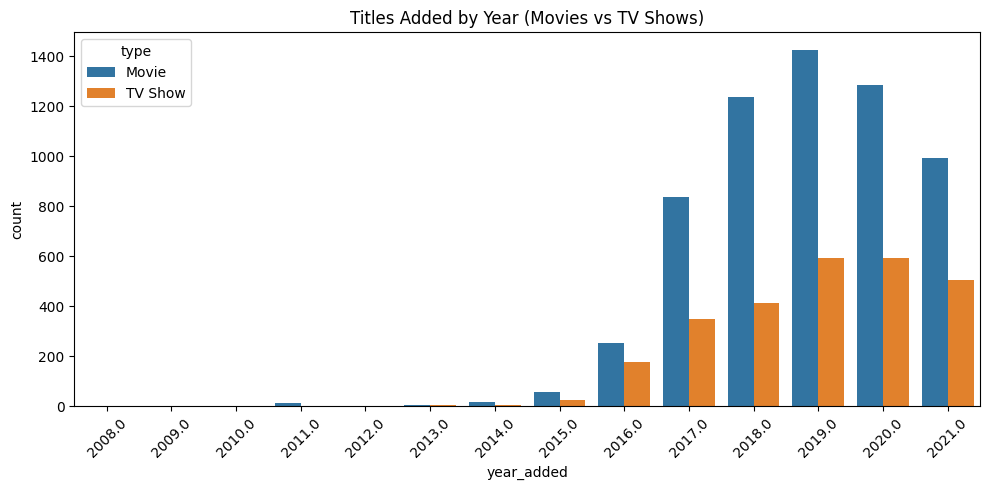

In [10]:
plt.figure(figsize=(10,5))
plot_df = df.dropna(subset=["year_added", "type"])
sns.countplot(data=plot_df, x="year_added", hue="type")
plt.title("Titles Added by Year (Movies vs TV Shows)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


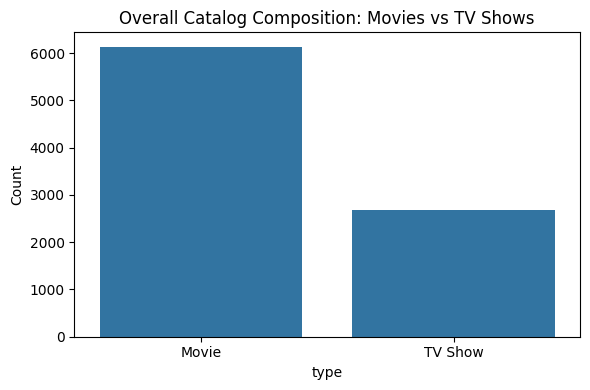

In [12]:
type_counts = df["type"].value_counts(dropna=False)
type_counts

plt.figure(figsize=(6,4))
sns.barplot(x=type_counts.index, y=type_counts.values)
plt.title("Overall Catalog Composition: Movies vs TV Shows")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


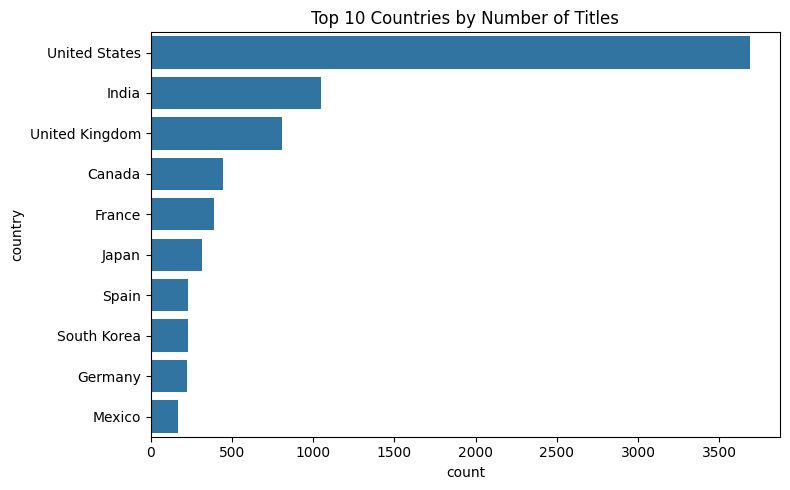

In [13]:
top_countries = df_countries["country"].value_counts().head(10).reset_index()
top_countries.columns = ["country", "count"]
top_countries

plt.figure(figsize=(8,5))
sns.barplot(data=top_countries, y="country", x="count")
plt.title("Top 10 Countries by Number of Titles")
plt.tight_layout()
plt.show()


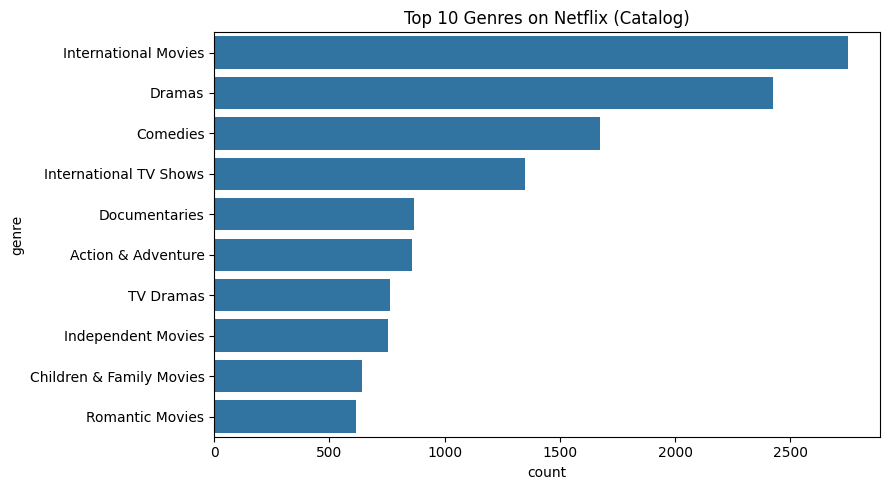

In [14]:
top_genres = df_genres["listed_in"].value_counts().head(10).reset_index()
top_genres.columns = ["genre", "count"]
top_genres

plt.figure(figsize=(9,5))
sns.barplot(data=top_genres, y="genre", x="count")
plt.title("Top 10 Genres on Netflix (Catalog)")
plt.tight_layout()
plt.show()


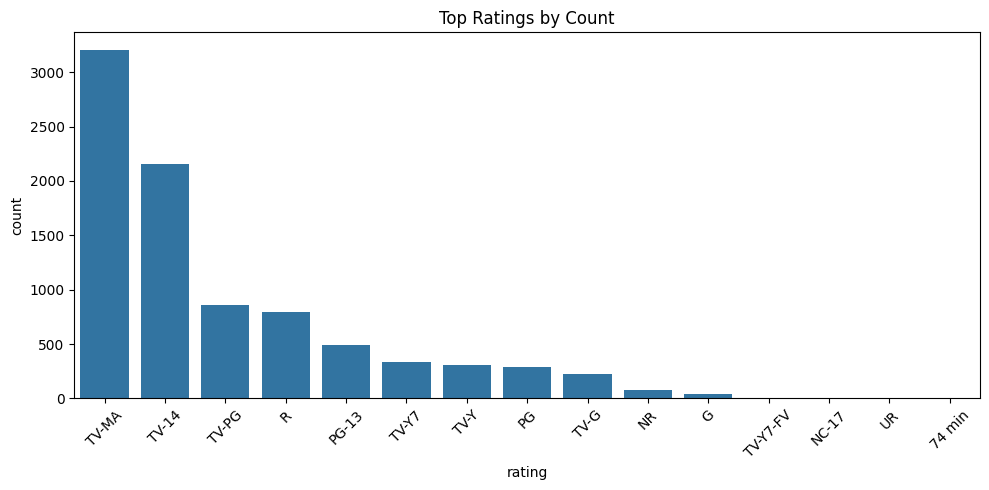

In [15]:
rating_counts = df["rating"].value_counts().head(15).reset_index()
rating_counts.columns = ["rating", "count"]
rating_counts

plt.figure(figsize=(10,5))
sns.barplot(data=rating_counts, x="rating", y="count")
plt.title("Top Ratings by Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


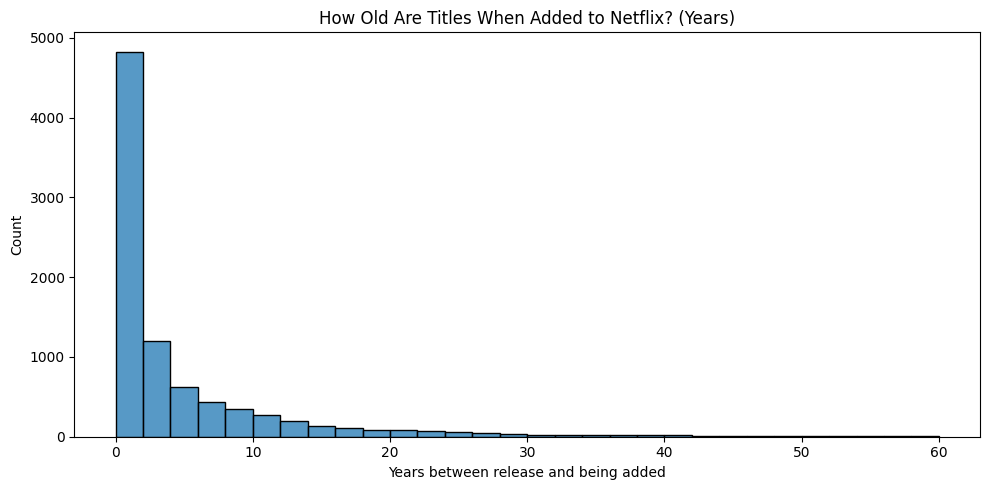

In [16]:
lag_df = df.dropna(subset=["content_age_lag"])
lag_df = lag_df[(lag_df["content_age_lag"] >= 0) & (lag_df["content_age_lag"] <= 60)]  # keep reasonable range

plt.figure(figsize=(10,5))
sns.histplot(data=lag_df, x="content_age_lag", bins=30)
plt.title("How Old Are Titles When Added to Netflix? (Years)")
plt.xlabel("Years between release and being added")
plt.tight_layout()
plt.show()


In [17]:
summary = {
    "total_titles": len(df),
    "movies": int((df["type"] == "Movie").sum()),
    "tv_shows": int((df["type"] == "TV Show").sum()),
    "unique_countries": int(df_countries["country"].nunique()),
    "unique_genres": int(df_genres["listed_in"].nunique()),
    "min_release_year": int(df["release_year"].min()),
    "max_release_year": int(df["release_year"].max()),
}
pd.DataFrame([summary])


,total_titles,movies,tv_shows,unique_countries,unique_genres,min_release_year,max_release_year
0,8807,6131,2676,122,42,1925,2021


## Validation / Reasonableness Checks

To ensure the input data and outputs were correct:

- Verified the dataset row/column count matched expectations after loading.
- Checked missing values by column and noted which fields were incomplete (e.g., director/cast/country).
- Converted `date_added` to datetime and counted parsing failures (`NaT`) to avoid silent errors.
- Created `content_age_lag = year_added - release_year` and inspected negative/outlier values as a sanity check.
- For multi-value fields like `country` and `listed_in`, I split on commas and inspected top results to confirm parsing looked reasonable.

Where I chose to utilize AI assistance for any code snippets, I:
- ran the code end-to-end in the notebook to verify structure and flow,
- compared outputs against pandas documentation expectations,
- and spot-checked a small sample of raw rows to confirm transformations were correct.
